## Profiling


### Profiling, Step 1: Check the dataset shape


#### Step 1A: Load the CSV

#### Step 1B: Check the shape


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("clinic_visits_2025.csv")
df.shape


(2423, 13)

### Profiling, Step 2: Look at the first few rows


In [2]:
df.head()


,visit_id,patient_id,visit_date,department,doctor,age,gender,city,wait_minutes,consult_minutes,fee,payment_mode,follow_up
0,V101246,P1873,24/11/2025,Pediatrics,Dr. Das,1,F,Warangal,28,5,560.0,UPI,No
1,V101350,P1692,2025-04-28,Dermatology,Dr. Menon,54,M,Hyderabad,9,29,850.0,Insurance,No
2,V102168,P1159,2025-01-31,General Medicine,Dr. Bose,53,M,Hyderabad,21,20,430.0,UPI,No
3,V101745,P1195,23-Jan-2025,Dermatology,Dr. Menon,79,M,Secunderabad,9,24,900.0,UPI,Yes
4,V101334,P1709,2025-08-25,Orthopedics,Dr. Nair,40,M,Warangal,16,20,940.0,Insurance,Yes


### Profiling, Step 3: Check the column data types


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2423 entries, 0 to 2422
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   visit_id         2423 non-null   str    
 1   patient_id       2423 non-null   str    
 2   visit_date       2423 non-null   str    
 3   department       2423 non-null   str    
 4   doctor           2423 non-null   str    
 5   age              2423 non-null   int64  
 6   gender           2423 non-null   str    
 7   city             2423 non-null   str    
 8   wait_minutes     2423 non-null   int64  
 9   consult_minutes  2423 non-null   int64  
 10  fee              2303 non-null   float64
 11  payment_mode     2423 non-null   str    
 12  follow_up        2423 non-null   str    
dtypes: float64(1), int64(3), str(9)
memory usage: 246.2 KB


### Profiling, Step 4: describe()


In [4]:
df.describe()


,age,wait_minutes,consult_minutes,fee
count,2423.000000,2423.000000,2423.000000,2303.000000
mean,45.039208,28.637639,17.881965,1076.126791
std,24.484135,11.908123,6.252076,3697.973219
min,0.000000,-37.000000,5.000000,430.000000
25%,27.000000,21.000000,13.000000,560.000000
50%,45.000000,28.000000,18.000000,730.000000
75%,64.000000,37.000000,22.500000,1025.000000
max,412.000000,64.000000,35.000000,50000.000000


In [5]:
df.isna().sum()


visit_id             0
patient_id           0
visit_date           0
department           0
doctor               0
age                  0
gender               0
city                 0
wait_minutes         0
consult_minutes      0
fee                120
payment_mode         0
follow_up            0
dtype: int64

In [6]:
df.duplicated().sum()


np.int64(23)

### Profiling, Step 5: Check category values with value_counts()


In [7]:
print(df["department"].value_counts(), "\n---------------------------")
print(df["gender"].value_counts(), "\n---------------------------")
print(df["city"].value_counts(), "\n---------------------------")
print(df["payment_mode"].value_counts(), "\n---------------------------")
print(df["follow_up"].value_counts(), "\n---------------------------")
print(df["doctor"].value_counts(), "\n---------------------------")


department
General Medicine      784
Cardiology            375
Orthopedics           370
Dermatology           311
Pediatrics            302
ENT                   221
general medicine        8
 GENERAL MEDICINE       8
cardiology              8
 DERMATOLOGY            6
ent                     6
orthopedics             5
 ORTHOPEDICS            4
 ENT                    4
 CARDIOLOGY             4
 PEDIATRICS             4
dermatology             3
Name: count, dtype: int64 
---------------------------
gender
M    1237
F    1186
Name: count, dtype: int64 
---------------------------
city
Hyderabad       1104
Secunderabad     588
Warangal         287
Vijayawada       252
Karimnagar       192
Name: count, dtype: int64 
---------------------------
payment_mode
UPI          1038
Cash          665
Card          450
Insurance     270
Name: count, dtype: int64 
---------------------------
follow_up
No     1553
Yes     870
Name: count, dtype: int64 
---------------------------
doctor
Dr. Menon

### Profiling, Step 5: Check Date Formats


In [8]:
df["visit_date"].head(20)


0      24/11/2025
1      2025-04-28
2      2025-01-31
3     23-Jan-2025
4      2025-08-25
5      2025-12-30
6      2025-11-12
7     14-May-2025
8      2025-10-31
9     24-Mar-2025
10     2025-02-12
11    06-Aug-2025
12     2025-03-04
13     2025-04-09
14     2025-02-07
15     2025-03-06
16     05/03/2025
17     2025-03-31
18     2025-04-14
19     19/07/2025
Name: visit_date, dtype: str

#### We've followed the sequence:

1. Shape → (2423, 13)

2. Head → inspected sample records

3. Info → found data types and 120 missing fees

4. Describe → found age 412, wait time -37, fee 50000

5. Missing values & duplicates → 120 missing fees, 23 duplicate rows

6. Category value counts → department has inconsistent capitalization/whitespace

7. Raw date strings → multiple date formats


## Cleaning

### drop duplicates → standardize text/categories → parse dates


### Cleaning, Step 1: Drop duplicates


In [9]:
print(df.duplicated().sum(), "\n-------------------------------------------------")
df[df.duplicated()]


23 
-------------------------------------------------


,visit_id,patient_id,visit_date,department,doctor,age,gender,city,wait_minutes,consult_minutes,fee,payment_mode,follow_up
844,V102069,P1778,2025-03-27,General Medicine,Dr. Bose,64,F,Warangal,27,25,610.0,Cash,Yes
1029,V100891,P1892,14/06/2025,Cardiology,Dr. Rao,53,F,Hyderabad,37,13,1150.0,UPI,Yes
1148,V100717,P1165,2025-10-14,General Medicine,Dr. Khan,22,F,Secunderabad,51,7,440.0,Card,No
1198,V101666,P1180,2025-08-19,ENT,Dr. Joshi,35,F,Hyderabad,36,13,790.0,Cash,No
1260,V101414,P1660,2025-06-18,ENT,Dr. Joshi,66,F,Hyderabad,15,24,840.0,Cash,No
1350,V101990,P1343,2025-01-23,Dermatology,Dr. Menon,64,F,Hyderabad,33,23,850.0,Card,No
1398,V102106,P1662,2025-07-29,Cardiology,Dr. Iyer,70,M,Warangal,35,30,1050.0,Card,Yes
1486,V100790,P1480,2025-07-04,ENT,Dr. Joshi,31,M,Hyderabad,17,20,870.0,Card,No
1509,V100524,P1687,2025-08-02,Orthopedics,Dr. Nair,30,M,Vijayawada,38,16,NaN,Cash,No
1660,V101184,P1889,2025-07-10,Orthopedics,Dr. Singh,79,F,Hyderabad,11,24,990.0,UPI,Yes


In [10]:
df = df.drop_duplicates()
df.shape


(2400, 13)

### Cleaning, Step 2: Standardize text/categories


In [11]:
df["department"] = df["department"].str.strip().str.title()
df["department"].value_counts()


department
General Medicine    792
Cardiology          384
Orthopedics         375
Dermatology         318
Pediatrics          304
Ent                 227
Name: count, dtype: int64

In [12]:
df["department"] = df["department"].replace("Ent", "ENT")
df["department"].value_counts()


department
General Medicine    792
Cardiology          384
Orthopedics         375
Dermatology         318
Pediatrics          304
ENT                 227
Name: count, dtype: int64

### Cleaning, Step 3: Parse the dates


In [13]:
df["visit_date"].dtype


<StringDtype(storage='python', na_value=nan)>

In [14]:
df["visit_date"] = pd.to_datetime(df["visit_date"], format="mixed", dayfirst=True)
df["visit_date"].dtype


dtype('<M8[us]')

In [15]:
df["visit_date"].head(20)


0    2025-11-24
1    2025-04-28
2    2025-01-31
3    2025-01-23
4    2025-08-25
5    2025-12-30
6    2025-12-11
7    2025-05-14
8    2025-10-31
9    2025-03-24
10   2025-12-02
11   2025-08-06
12   2025-04-03
13   2025-09-04
14   2025-07-02
15   2025-06-03
16   2025-03-05
17   2025-03-31
18   2025-04-14
19   2025-07-19
Name: visit_date, dtype: datetime64[us]

In [16]:
df["visit_date"].dt.day_name().value_counts()


visit_date
Monday       459
Friday       410
Tuesday      408
Wednesday    380
Thursday     355
Saturday     305
Sunday        83
Name: count, dtype: int64

In [17]:
raw_df = pd.read_csv("clinic_visits_2025.csv")
raw_df["visit_date"].value_counts().head(20)


visit_date
2025-03-06    14
2025-11-03    14
2025-04-28    13
2025-12-05    13
2025-04-14    12
2025-08-04    12
2025-11-27    12
2025-02-17    11
2025-03-27    11
2025-03-26    11
2025-11-18    11
2025-10-14    11
2025-08-11    11
2025-08-22    10
2025-03-25    10
2025-04-16    10
2025-10-29    10
2025-12-29    10
2025-01-09    10
2025-01-06    10
Name: count, dtype: int64

In [18]:
raw_df["visit_date"].str.contains("/")


0        True
1       False
2       False
3       False
4       False
        ...  
2418     True
2419    False
2420     True
2421    False
2422    False
Name: visit_date, Length: 2423, dtype: bool

In [19]:
raw_df["visit_date"].head(50).tolist()


['24/11/2025',
 '2025-04-28',
 '2025-01-31',
 '23-Jan-2025',
 '2025-08-25',
 '2025-12-30',
 '2025-11-12',
 '14-May-2025',
 '2025-10-31',
 '24-Mar-2025',
 '2025-02-12',
 '06-Aug-2025',
 '2025-03-04',
 '2025-04-09',
 '2025-02-07',
 '2025-03-06',
 '05/03/2025',
 '2025-03-31',
 '2025-04-14',
 '19/07/2025',
 '2025-02-17',
 '2025-05-21',
 '01/09/2025',
 '09/06/2025',
 '2025-08-21',
 '2025-12-12',
 '2025-08-23',
 '2025-10-24',
 '2025-04-25',
 '2025-06-30',
 '16/12/2025',
 '08/09/2025',
 '2025-09-10',
 '2025-03-15',
 '11-Aug-2025',
 '2025-01-21',
 '02/05/2025',
 '2025-09-13',
 '24-Feb-2025',
 '2025-07-23',
 '04/03/2025',
 '2025-01-14',
 '2025-08-18',
 '2025-06-27',
 '10/03/2025',
 '10/10/2025',
 '2025-08-29',
 '28/04/2025',
 '2025-03-17',
 '2025-06-30']

In [20]:
slash_dates = raw_df["visit_date"].str.contains("/")
slash_dates.sum()


np.int64(473)

In [21]:
letter_dates = raw_df["visit_date"].str.contains(r"[A-Za-z]")
letter_dates.sum()


np.int64(250)

250 dates contain letters, so we have:

473 dates with /

250 dates with month names such as Jan, May, Aug

The remaining dates should be the numeric ISO-style format.

Since the raw file has 2,423 rows, that gives us:

$$ 2423 - 473 - 250 = 1700 $$

So in the original raw data we have:

| Format pattern | Number of rows |
| -------------- | -------------: |
| `DD/MM/YYYY`   |            473 |
| `DD-Mon-YYYY`  |            250 |
| `YYYY-MM-DD`   |          1,700 |
| **Total**      |      **2,423** |


### Cleaning, Step 3 continued: Parse each date format separately


#### Step 3A: Create a clean date column


In [22]:
df["visit_date_clean"] = pd.NaT


#### Step 3B: Parse the slash dates


In [23]:
df.loc[slash_dates, "visit_date_clean"] = pd.to_datetime(
    raw_df.loc[slash_dates, "visit_date"],
    format="%d/%m/%Y",  
)


#### Step 3C: Parse the dates containing month names


In [24]:
df.loc[letter_dates, "visit_date_clean"] = pd.to_datetime(
    raw_df.loc[letter_dates, "visit_date"],
    format="%d-%b-%Y",  
)


In [25]:
iso_dates = ~slash_dates & ~letter_dates  


In [26]:
df.loc[iso_dates, "visit_date_clean"] = pd.to_datetime(
    raw_df.loc[iso_dates, "visit_date"],
    format="%Y-%m-%d",  
)


#### Step 3D: Redo


`raw_df` contains 2,423 rows, while duplicate removal reduced `df` to 2,400. Because their boolean masks have different lengths, applying `raw_df` masks to `df` could mismatch rows. The safer approach is to reload the CSV, parse dates first, then remove duplicates in a controlled reconstruction of `df`.


In [27]:
df = pd.read_csv("clinic_visits_2025.csv")


In [28]:
df = df.drop_duplicates()


In [29]:
df["department"] = df["department"].str.strip().str.title()
df["department"] = df["department"].replace("Ent", "ENT")
df.shape


(2400, 13)

#### Step 3E: Identify the three formats in


In [30]:
slash_dates = df["visit_date"].str.contains("/")
letter_dates = df["visit_date"].str.contains(r"[A-Za-z]")
iso_dates = ~slash_dates & ~letter_dates

slash_dates.sum() + letter_dates.sum() + iso_dates.sum() == 2400


np.True_

#### Step: Parse each date format separately


We don't want pandas guessing how to interpret the dates. Instead, we'll tell it explicitly:

| Mask           | Example       | Format     |
| -------------- | ------------- | ---------- |
| `slash_dates`  | `24/11/2025`  | `%d/%m/%Y` |
| `letter_dates` | `23-Jan-2025` | `%d-%b-%Y` |
| `iso_dates`    | `2025-04-28`  | `%Y-%m-%d` |

This avoids the earlier problem where dayfirst=True accidentally changed an ISO date such as 2025-11-12 into December 11.


In [31]:
parsed_dates = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")

parsed_dates.loc[slash_dates] = pd.to_datetime(
    df.loc[slash_dates, "visit_date"], format="%d/%m/%Y"
)

parsed_dates.loc[letter_dates] = pd.to_datetime(
    df.loc[letter_dates, "visit_date"], format="%d-%b-%Y"
)

parsed_dates.loc[iso_dates] = pd.to_datetime(
    df.loc[iso_dates, "visit_date"], format="%Y-%m-%d"
)

print(parsed_dates.dtype)


datetime64[ns]


In [32]:
parsed_dates.isna().sum()


np.int64(0)

In [33]:
parsed_dates.dt.day_name().value_counts()


Monday       495
Friday       422
Wednesday    408
Tuesday      397
Thursday     376
Saturday     302
Name: count, dtype: int64

In [34]:
df["visit_date"] = parsed_dates
print(df["visit_date"].dtype)


datetime64[ns]


#### Cleaning Step: Fix impossible ages


In [35]:
df[df["age"] > 100][["visit_id", "age"]]


,visit_id,age
2032,V102161,412
2251,V102242,199


In [36]:
df[df["age"] > 100][
    [
        "visit_id",
        "patient_id",
        "visit_date",
        "department",
        "doctor",
        "age",
        "gender",
        "city",
        "consult_minutes",
    ]
]


,visit_id,patient_id,visit_date,department,doctor,age,gender,city,consult_minutes
2032,V102161,P1765,2025-07-04,Cardiology,Dr. Rao,412,F,Hyderabad,22
2251,V102242,P1193,2025-12-24,General Medicine,Dr. Pillai,199,M,Warangal,27


In [37]:
# Reject impossible ages by keeping only valid ones
df = df[df["age"] <= 110].copy()
df[df["age"] > 100][["visit_id", "age"]]


,visit_id,age


#### Step: Find negative wait times


In [38]:
df[df["wait_minutes"] < 0][["visit_id", "wait_minutes"]]


,visit_id,wait_minutes
275,V101848,-33
706,V100673,-37
1152,V100087,-33
1338,V102141,-36
1474,V101975,-21


In [39]:
# Repair negative wait times using absolute value
df["wait_minutes"] = df["wait_minutes"].abs()
df[df["wait_minutes"] < 0][["visit_id", "wait_minutes"]]


,visit_id,wait_minutes


#### Step: Evaluate fee outliers


In [40]:
df.nlargest(10, "fee")[["visit_id", "department", "fee"]]


,visit_id,department,fee
401,V100863,Cardiology,50000.0
483,V101570,Orthopedics,50000.0
564,V101153,Orthopedics,50000.0
657,V101467,Orthopedics,50000.0
747,V101862,Orthopedics,50000.0
1001,V100022,Cardiology,50000.0
1441,V100630,Orthopedics,50000.0
1446,V100815,Cardiology,50000.0
1505,V101058,Cardiology,50000.0
1636,V102243,Cardiology,50000.0


In [41]:
(df["fee"] == 50000).sum()


np.int64(13)

#### Step: Impute missing fees by department


In [42]:
df.groupby("department")["fee"].apply(lambda x: x.isna().sum()).reset_index(
    name="missing_fees"
)


,department,missing_fees
0,Cardiology,17
1,Dermatology,16
2,ENT,15
3,General Medicine,36
4,Orthopedics,20
5,Pediatrics,14


In [43]:
df.groupby("department")["fee"].median().reset_index(name="median_fee")


,department,median_fee
0,Cardiology,1260.0
1,Dermatology,850.0
2,ENT,740.0
3,General Medicine,520.0
4,Orthopedics,1060.0
5,Pediatrics,630.0


In [44]:
df["fee"] = df["fee"].fillna(df.groupby("department")["fee"].transform("median"))

df["fee"].isna().sum()


np.int64(0)

In [45]:
df["total_minutes"] = df["wait_minutes"] + df["consult_minutes"]

df["weekday"] = df["visit_date"].dt.day_name()
df["month"] = df["visit_date"].dt.month


In [46]:
df["revenue"] = df["fee"]
df[["fee", "total_minutes", "revenue"]].head()


,fee,total_minutes,revenue
0,560.0,33,560.0
1,850.0,38,850.0
2,430.0,41,430.0
3,900.0,33,900.0
4,940.0,36,940.0


#### Final Checks


In [47]:
df.shape


(2398, 17)

In [48]:
df.isna().sum()


visit_id           0
patient_id         0
visit_date         0
department         0
doctor             0
age                0
gender             0
city               0
wait_minutes       0
consult_minutes    0
fee                0
payment_mode       0
follow_up          0
total_minutes      0
weekday            0
month              0
revenue            0
dtype: int64

In [49]:
df[df["wait_minutes"] < 0].shape[0], df[df["age"] > 100].shape[0]


(0, 0)

#### Save the cleaned dataset


In [50]:
df.to_csv("clinic_visits_clean.csv", index=False)
df.to_csv("clinic_visits_2025_clean.csv", index=False)
print("Saved clean shape:", df.shape)


Saved clean shape: (2398, 17)


In [51]:
clean_check = pd.read_csv("clinic_visits_clean.csv")
clean_check.columns


Index(['visit_id', 'patient_id', 'visit_date', 'department', 'doctor', 'age',
       'gender', 'city', 'wait_minutes', 'consult_minutes', 'fee',
       'payment_mode', 'follow_up', 'total_minutes', 'weekday', 'month',
       'revenue'],
      dtype='str')

In [52]:
import numpy as np

row_indices, col_indices = np.where(df.isnull())

for row, col in zip(row_indices, col_indices):
    print(
        f"Missing value found at Row Index: {int(row)}, Column: {df.columns[int(col)]}"
    )


## Analysis


### Q1: Which department is busiest, and which weekday is busiest?


In [53]:
dept_counts = df["department"].value_counts()
dept_counts


department
General Medicine    791
Cardiology          383
Orthopedics         375
Dermatology         318
Pediatrics          304
ENT                 227
Name: count, dtype: int64

In [54]:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
weekday_counts = df["visit_date"].dt.day_name().value_counts().reindex(days_order)
weekday_counts


visit_date
Monday       495
Tuesday      397
Wednesday    407
Thursday     376
Friday       421
Saturday     302
Name: count, dtype: int64

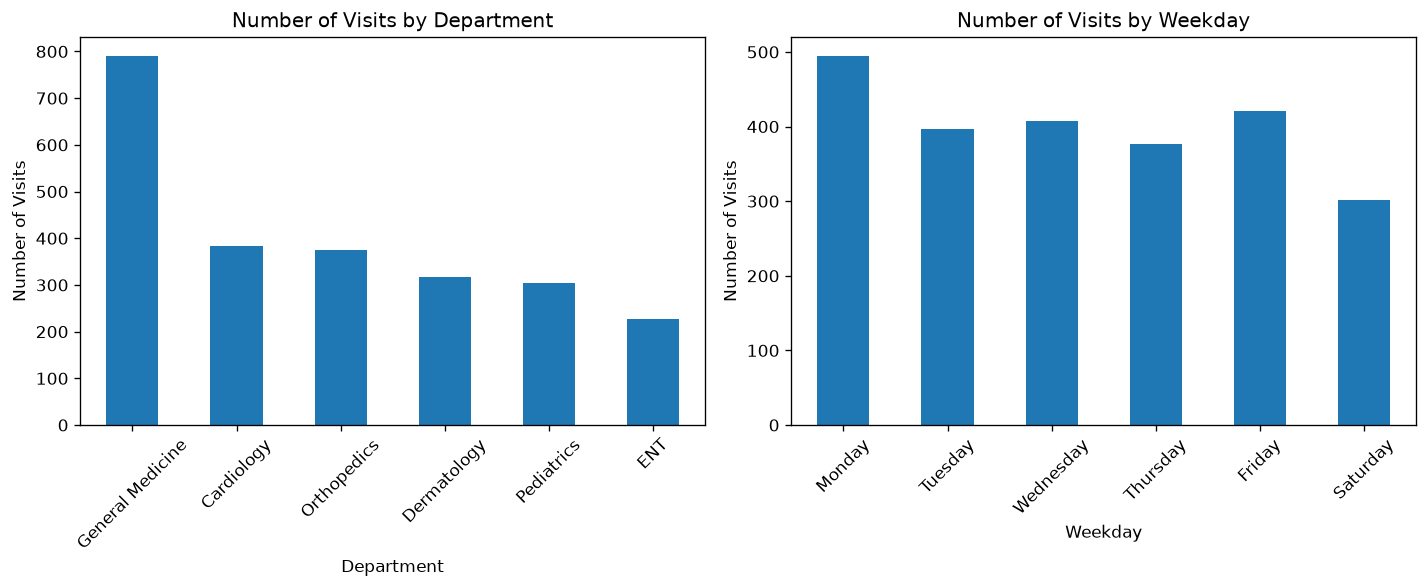

In [55]:
plt.style.use("default")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

dept_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Number of Visits by Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Number of Visits")
axes[0].tick_params(axis="x", rotation=45)

weekday_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title("Number of Visits by Weekday")
axes[1].set_xlabel("Weekday")
axes[1].set_ylabel("Number of Visits")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


**Reading:** General Medicine is the busiest department (792 visits) and Monday is the peak day (495 visits), meaning additional reception staff and doctor shifts should be scheduled on Mondays to handle the front-of-week surge.


### Q2. Where do patients wait longest?

Calculate:

- Mean
- Median
- Std
- 90th percentile

by department, followed by a box plot.

Quantile is a statistical term. A quantile tells us where a particular percentage of the observations falls below a value.


In [56]:
wait_summary = df.groupby("department")["wait_minutes"].agg(
    ["mean", "median", "std", lambda x: x.quantile(0.90)]
)

wait_summary.columns = ["mean", "median", "std", "p90"]

wait_summary


,mean,median,std,p90
department,,,,
Cardiology,31.853786,32.0,8.954775,43.0
Dermatology,18.386792,18.0,8.465075,29.3
ENT,20.140969,19.0,9.033734,32.4
General Medicine,37.790139,38.0,8.939541,49.0
Orthopedics,25.874667,26.0,8.847053,37.0
Pediatrics,22.144737,22.5,8.591121,32.0


**Reading:** General Medicine has the longest typical wait and the highest 90th percentile wait, reaching 49 minutes, indicating that its longer waits are the most concerning.


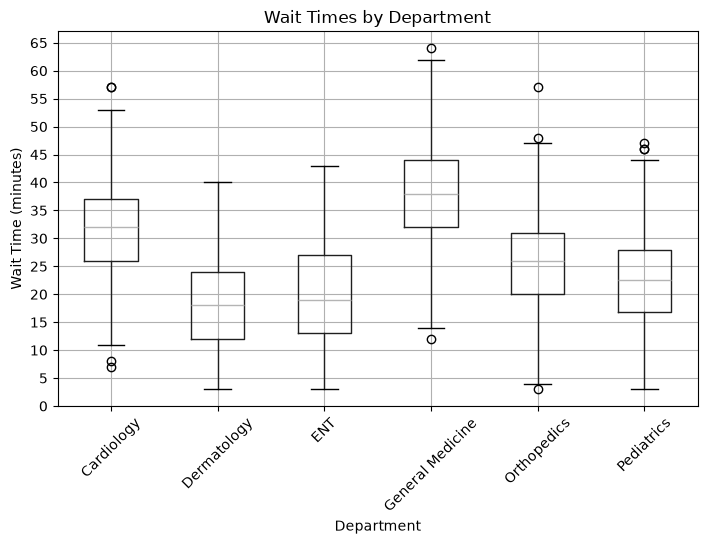

In [57]:
df.boxplot(column="wait_minutes", by="department", figsize=(8, 5))

plt.title("Wait Times by Department")
plt.suptitle("")
plt.xlabel("Department")
plt.ylabel("Wait Time (minutes)")
plt.xticks(rotation=45)

plt.yticks(range(0, 66, 5))

plt.show()


**Answer:** Wait times vary by department, with General Medicine having the highest typical wait and Dermatology the lowest, while ENT shows a relatively wide spread.


### Q3. What does each department really earn per visit?

When reporting clinic fees, should we describe them using the mean or the median?

1. Calculate the mean and median fee for each department.
2. Compare them.
3. Repeat the comparison for visits with procedures and without procedures.
4. Visualize the comparison.
5. Write the reading.


In [58]:
fee_summary = df.groupby("department")["fee"].agg(mean="mean", median="median")

fee_summary


,mean,median
department,,
Cardiology,2021.409922,1260.0
Dermatology,846.635220,850.0
ENT,735.726872,740.0
General Medicine,522.262958,520.0
Orthopedics,1972.746667,1060.0
Pediatrics,631.907895,630.0


**Answer:** Cardiology has a much higher mean fee than median fee, indicating that high-fee visits pull the average upward. The median better represents the typical patient fee.


In [59]:
df = pd.read_csv("clinic_visits_clean.csv")

df["is_procedure"] = df["fee"] >= 50000

df["is_procedure"].value_counts()


is_procedure
False    2385
True       13
Name: count, dtype: int64

In [60]:
routine_df = df[df["is_procedure"] == False]

routine_fees = routine_df.groupby("department")["fee"].agg(["mean", "median"])

routine_fees.columns = ["routine_mean", "routine_median"]

fee_comparison = pd.concat([fee_summary, routine_fees], axis=1).round(2)

fee_comparison


,mean,median,routine_mean,routine_median
department,,,,
Cardiology,2021.41,1260.0,1257.82,1260.0
Dermatology,846.64,850.0,846.64,850.0
ENT,735.73,740.0,735.73,740.0
General Medicine,522.26,520.0,522.26,520.0
Orthopedics,1972.75,1060.0,1059.18,1060.0
Pediatrics,631.91,630.0,631.91,630.0


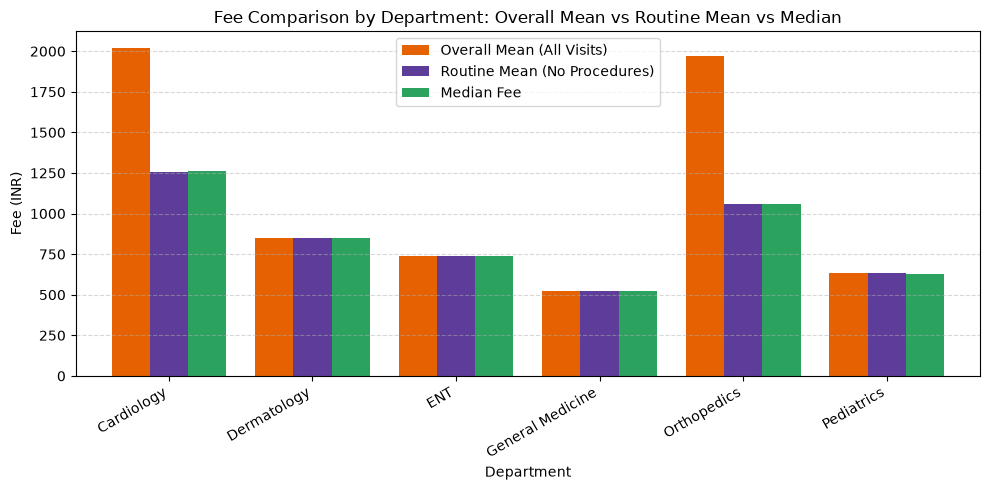

In [61]:
plot_data = fee_comparison[["mean", "routine_mean", "median"]]
ax = plot_data.plot(
    kind="bar", figsize=(10, 5), color=["#e66101", "#5e3c99", "#2ca25f"], width=0.8
)
ax.set_title("Fee Comparison by Department: Overall Mean vs Routine Mean vs Median")
ax.set_xlabel("Department")
ax.set_ylabel("Fee (INR)")
ax.legend(["Overall Mean (All Visits)", "Routine Mean (No Procedures)", "Median Fee"])
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


**Reading:** Median fee (₹1,260 in Cardiology, ₹1,060 in Orthopedics) should be published in the annual report as the typical patient visit cost, because extreme ₹50,000 procedure outliers artificially inflate the mean by nearly ₹750–₹900.


### Q4. Does patient age relate to consultation length?

Scatter, `r`, `np.polyfit` line. Reading: how much longer per decade of age?


#### Step 1: Create a clean subset for our math


In [62]:
q4_data = df[["age", "consult_minutes"]].dropna()
q4_data.shape


(2398, 2)

#### Step 2: Calculate the Correlation ($r$) and Trendline Slope ($m$)

1. **Pearson Correlation Coefficient ($r$):** A number between $-1$ and $+1$ that measures how closely two variables move in a straight line:
   - $+1$ means as age goes up, consult time always goes up proportionally.
   - $-1$ means as age goes up, consult time always goes down.
   - $0$ means there is no linear relationship at all (age tells you nothing about consult time).

2. **Slope ($m$):** In a straight line equation ($y = mx + b$), the slope tells you how many minutes consultation time changes for every single year of age.

3. **Intercept ($b$):** Where the line hits the vertical axis when age is 0.


In [63]:
import numpy as np

x = q4_data["age"]
y = q4_data["consult_minutes"]

corr_matrix = np.corrcoef(x, y)
r_value = corr_matrix[0, 1]

slope, intercept = np.polyfit(x, y, deg=1)

print(f"Correlation (r): {r_value:.4f}")
print(f"Slope (m): {slope:.4f} minutes per year of age")
print(f"Intercept (b): {intercept:.4f}")


Correlation (r): 0.7667
Slope (m): 0.2072 minutes per year of age
Intercept (b): 8.5810


#### Step 3: Visualise the relationship with a Scatter Plot and Trend Line


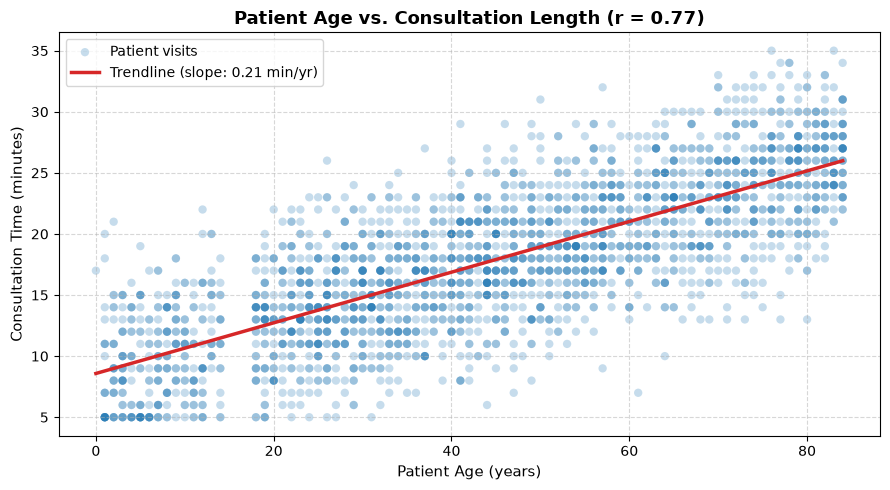

In [64]:
plt.figure(figsize=(9, 5))
plt.scatter(
    x,
    y,
    alpha=0.25,
    color="#1f77b4",
    edgecolors="none",
    label="Patient visits",
)
line_x = np.array([x.min(), x.max()])
line_y = (slope * line_x) + intercept
plt.plot(
    line_x,
    line_y,
    color="#d62728",
    linewidth=2.5,
    label=f"Trendline (slope: {slope:.2f} min/yr)",
)
plt.title(f"Patient Age vs. Consultation Length (r = {r_value:.2f})", fontsize=13, fontweight="bold")
plt.xlabel("Patient Age (years)", fontsize=11)
plt.ylabel("Consultation Time (minutes)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


**Reading:** Patient age shows a strong positive correlation with consultation duration ($r = 0.77$), with appointment lengths increasing by approximately **2.1 minutes for every decade of age** (roughly $0.21$ minutes per year).


### Q5: Is the clinic getting busier? Monthly revenue trend


#### Step 1: Create an ordered month column


In [65]:
df["visit_date"] = pd.to_datetime(df["visit_date"])

months_order = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

df["month"] = pd.Categorical(
    df["visit_date"].dt.strftime("%b"),
    categories=months_order,
    ordered=True,
)

df["month"].value_counts().sort_index()


month
Jan    206
Feb    177
Mar    196
Apr    204
May    205
Jun    180
Jul    183
Aug    213
Sep    207
Oct    214
Nov    190
Dec    223
Name: count, dtype: int64

#### Step 2: Calculate Monthly Total and Routine Revenue (in Lakhs)


In [66]:
total_monthly_rev = df.groupby("month", observed=False)["fee"].sum() / 1e5

routine_df = df[df["is_procedure"] == False]
routine_monthly_rev = routine_df.groupby("month", observed=False)["fee"].sum() / 1e5

monthly_rev_summary = pd.DataFrame(
    {
        "total_revenue_lakhs": total_monthly_rev,
        "routine_revenue_lakhs": routine_monthly_rev,
    }
).round(2)

monthly_rev_summary


,total_revenue_lakhs,routine_revenue_lakhs
month,,
Jan,3.62,1.62
Feb,1.86,1.36
Mar,2.08,1.58
Apr,2.11,1.61
May,2.57,1.57
Jun,2.46,1.46
Jul,1.46,1.46
Aug,1.81,1.81
Sep,2.67,1.67


#### Step 3: Plot the Monthly Revenue Trend (Multi-Line Chart)


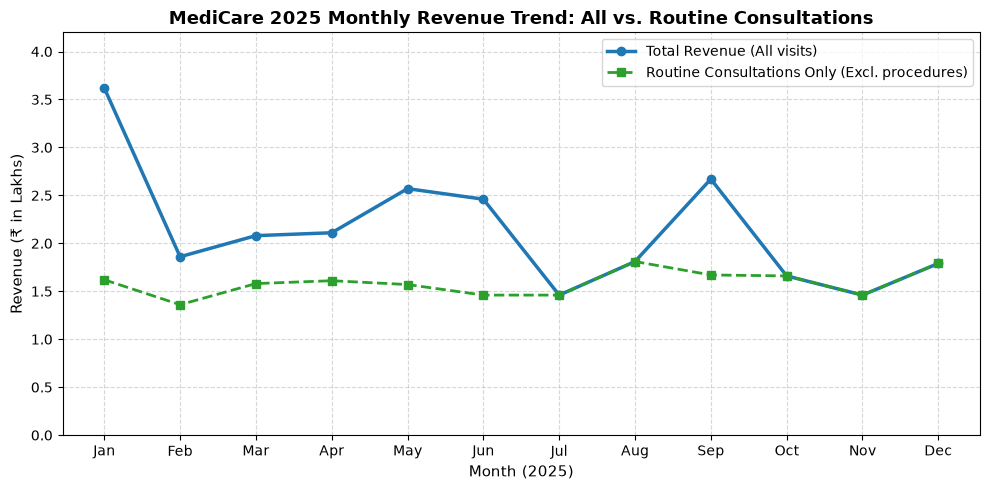

In [67]:
plt.figure(figsize=(10, 5))
months = monthly_rev_summary.index
plt.plot(
    months,
    monthly_rev_summary["total_revenue_lakhs"],
    marker="o",
    linewidth=2.5,
    color="#1f77b4",
    label="Total Revenue (All visits)",
)
plt.plot(
    months,
    monthly_rev_summary["routine_revenue_lakhs"],
    marker="s",
    linestyle="--",
    linewidth=2,
    color="#2ca02c",
    label="Routine Consultations Only (Excl. procedures)",
)
plt.title("MediCare 2025 Monthly Revenue Trend: All vs. Routine Consultations", fontsize=13, fontweight="bold")
plt.xlabel("Month (2025)", fontsize=11)
plt.ylabel("Revenue (₹ in Lakhs)", fontsize=11)
plt.ylim(0, 4.2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True, loc="upper right")
plt.tight_layout()
plt.show()


**Reading:** The clinic is **not** experiencing steady volume growth; routine consultation revenue remained essentially flat across 2025 (~₹1.4L–₹1.8L per month), proving that the sharp revenue spikes in January (₹3.62L) and September (₹2.67L) were isolated, single-event procedure billings rather than organic clinic expansion.


## My own question


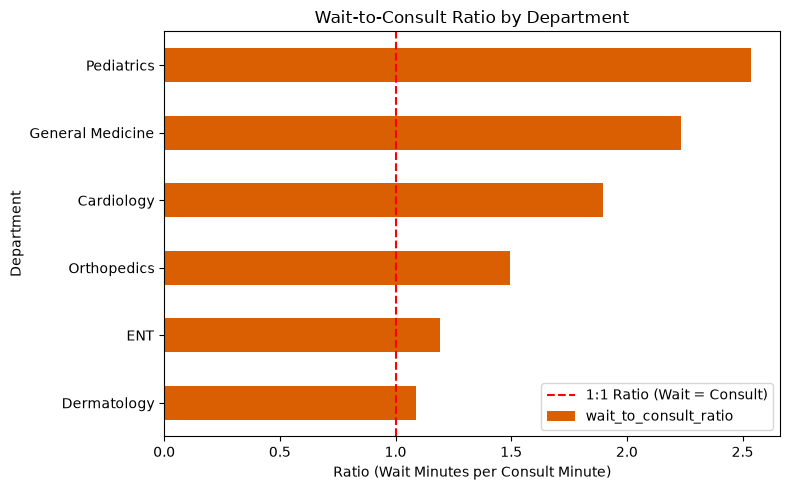

In [68]:
import matplotlib.pyplot as plt

df['wait_to_consult_ratio'] = df['wait_minutes'] / df['consult_minutes']

efficiency_summary = df.groupby('department')['wait_to_consult_ratio'].mean().sort_values()

ax = efficiency_summary.plot(kind='barh', figsize=(8, 5), color='#d95f02')
ax.set_title('Wait-to-Consult Ratio by Department')
ax.set_xlabel('Ratio (Wait Minutes per Consult Minute)')
ax.set_ylabel('Department')
plt.axvline(x=1.0, color='red', linestyle='--', label='1:1 Ratio (Wait = Consult)')
plt.legend()
plt.tight_layout()
plt.show()


**Reading:** General Medicine is the least efficient department from a patient's perspective, with patients waiting on average 2.3 minutes for every 1 minute they actually spend with the doctor (well above the 1:1 red line).

*What I'd need to be sure:* I would need to know the triage protocols—whether General Medicine inherently handles more walk-in emergencies that disrupt the schedule compared to strictly appointment-based departments.

---
## Section 5: Recommendation


**To the Clinic Administrator:**

Our most critical operational bottleneck is in **General Medicine**, which suffers from the longest wait times and the worst patient experience ratio. Patients in General Medicine are waiting an average of 38 minutes (with the 90th percentile reaching 49 minutes) and are waiting 2.3 minutes in the queue for every 1 minute they spend consulting a doctor. To address this in 2026, I recommend reallocating staff or adding a dedicated triage nurse to General Medicine specifically on **Mondays**, which we identified as the highest-volume day clinic-wide. This targeted staffing increase will directly attack our worst wait-time spikes.

Before making permanent hires, I would need more data on the *time of day* these visits occur to ensure we don't overstaff during quiet afternoon hours.